# Modelo Preditivo de Risco de Defasagem — Passos Mágicos

**Objetivo:** Construir um classificador binário que identifica, com base nos indicadores do aluno, se ele está em **risco de defasagem escolar** (defasagem ≥ 1 ano).

Este notebook cobre:
- Feature engineering sobre os indicadores da ONG
- Separação treino/teste estratificada
- Treinamento com Random Forest e XGBoost
- Avaliação com AUC-ROC, Precision, Recall e F1
- Exportação do modelo com joblib
- Explicabilidade com SHAP

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve, average_precision_score
)
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost não instalado — usando apenas Random Forest')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

BASE = '../data/'
MODEL_DIR = './'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Setup completo')

Setup completo


## 1 · Carregamento e preparação dos dados

In [2]:
def parse_float(s):
    if pd.isna(s):
        return np.nan
    try:
        return float(str(s).replace(',', '.'))
    except:
        return np.nan

def load_year(path, ano):
    df = pd.read_csv(path, encoding='latin1')
    df['ano'] = ano

    inde_col = [c for c in df.columns if 'INDE' in c and str(ano) in c]
    df['INDE'] = df[inde_col[0]].apply(parse_float) if inde_col else np.nan

    pedra_col = [c for c in df.columns if 'Pedra' in c and str(ano) in c]
    df['Pedra'] = df[pedra_col[0]] if pedra_col else np.nan

    if 'Defas' in df.columns:
        df['Defasagem'] = pd.to_numeric(df['Defas'], errors='coerce')
    elif 'Defasagem' in df.columns:
        df['Defasagem'] = pd.to_numeric(df['Defasagem'], errors='coerce')

    for col in ['IAN','IDA','IEG','IAA','IPS','IPP','IPV']:
        if col in df.columns:
            df[col] = df[col].apply(parse_float)
        else:
            df[col] = np.nan

    df['Fase'] = pd.to_numeric(df['Fase'], errors='coerce')
    df['Genero'] = df.get('Gênero', np.nan)

    return df

df22 = load_year(BASE + 'DATATHON - 2022.csv', 2022)
df23 = load_year(BASE + 'DATATHON - 2023.csv', 2023)
df24 = load_year(BASE + 'DATATHON - 2024.csv', 2024)

KEEP = ['RA','ano','Fase','Genero','Pedra','INDE','Defasagem',
        'IAN','IDA','IEG','IAA','IPS','IPP','IPV']

df = pd.concat([df22[KEEP], df23[KEEP], df24[KEEP]], ignore_index=True)
print('Dataset unificado:', df.shape)
df.head(3)

Dataset unificado: (3030, 14)


,RA,ano,Fase,Genero,Pedra,INDE,Defasagem,IAN,IDA,IEG,IAA,IPS,IPP,IPV
0,RA-1,2022,7.0,NaN,NaN,NaN,-1,5.0,4.0,4.1,8.3,5.6,NaN,7.278
1,RA-2,2022,7.0,NaN,NaN,NaN,0,10.0,6.8,5.2,8.8,6.3,NaN,6.778
2,RA-3,2022,7.0,NaN,NaN,NaN,0,10.0,5.6,7.9,0.0,5.6,NaN,7.556


## 2 · Feature Engineering

In [3]:
# ── Target ────────────────────────────────────────────────────────────────────
df['target'] = (df['Defasagem'] >= 1).astype(int)
print('Distribuição do target:')
print(df['target'].value_counts(normalize=True).round(3))

# ── Feature Engineering ───────────────────────────────────────────────────────
# Indicadores base
BASE_FEATURES = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'Fase']

# Features derivadas
df['ind_academico_medio'] = df[['IDA', 'IEG']].mean(axis=1)
df['ind_psico_medio'] = df[['IAA', 'IPS']].mean(axis=1)
df['gap_ian_fase'] = df['IAN'] - df['Fase'] * 0.5  # IAN relativo à fase
df['inde_x_ian'] = df['INDE'] * df['IAN']           # interação
df['baixo_ida'] = (df['IDA'] < 5).astype(float)     # flag de baixo desempenho
df['baixo_ieg'] = (df['IEG'] < 5).astype(float)
df['fase_sq'] = df['Fase'] ** 2                     # efeito não-linear da fase

# Gênero codificado
df['genero_cod'] = df['Genero'].map({'F': 0, 'M': 1, 'Feminino': 0, 'Masculino': 1})

# Pedra ordinal
pedra_map = {'Quartzo': 0, 'Ágata': 1, 'Ametista': 2, 'Topázio': 3}
df['pedra_ord'] = df['Pedra'].map(pedra_map)

FEATURE_COLS = BASE_FEATURES + [
    'ind_academico_medio', 'ind_psico_medio', 'gap_ian_fase',
    'inde_x_ian', 'baixo_ida', 'baixo_ieg', 'fase_sq',
    'genero_cod', 'pedra_ord'
]

print(f'\nTotal de features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Distribuição do target:
target
0    0.937
1    0.063
Name: proportion, dtype: float64

Total de features: 18
['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'Fase', 'ind_academico_medio', 'ind_psico_medio', 'gap_ian_fase', 'inde_x_ian', 'baixo_ida', 'baixo_ieg', 'fase_sq', 'genero_cod', 'pedra_ord']


In [4]:
# Remover linhas sem Defasagem definida (target derivado de NaN vira 0, não NaN)
df_model = df[df['Defasagem'].notna()][FEATURE_COLS + ['target', 'ano']].copy()
print(f'Registros com target válido: {len(df_model)}')
print(f'Taxa de positivos: {df_model["target"].mean():.1%}')

Registros com target válido: 3030
Taxa de positivos: 6.3%


## 3 · Separação Treino/Teste

In [5]:
# Split temporal em 3 partes: treino (2022) / calibração de threshold (2023) / teste (2024)
# Esta separação evita data leakage no threshold: o valor de corte é calibrado
# em dados não vistos pelo modelo e distintos do conjunto de avaliação final.
train_df = df_model[df_model['ano'] == 2022]
val_df   = df_model[df_model['ano'] == 2023]   # usado apenas para calibrar o threshold
test_df  = df_model[df_model['ano'] == 2024]

print(f"Treino  (2022): {len(train_df):>5} registros | positivos: {train_df['target'].mean():.1%}")
print(f"Val     (2023): {len(val_df):>5} registros | positivos: {val_df['target'].mean():.1%}")
print(f"Teste   (2024): {len(test_df):>5} registros | positivos: {test_df['target'].mean():.1%}")

X_train = train_df[FEATURE_COLS]
y_train = train_df['target']
X_val   = val_df[FEATURE_COLS]
y_val   = val_df['target']
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['target']

Treino  (2022):   860 registros | positivos: 1.4%
Val     (2023):  1014 registros | positivos: 4.1%
Teste   (2024):  1156 registros | positivos: 11.9%


In [6]:
print("=" * 55)
print("SHIFT DE DISTRIBUIÇÃO ENTRE OS CONJUNTOS")
print("=" * 55)
print(f"Taxa positivos TREINO (2022) : {y_train.mean():.1%}  ({y_train.sum()} / {len(y_train)})")
print(f"Taxa positivos VAL   (2023)  : {y_val.mean():.1%}  ({y_val.sum()} / {len(y_val)})")
print(f"Taxa positivos TESTE (2024)  : {y_test.mean():.1%}  ({y_test.sum()} / {len(y_test)})")
print()
print("⚠  O shift 2022→2024 indica que a prevalência de defasagem")
print("   aumentou ao longo dos anos. O threshold é calibrado em 2023")
print("   (conjunto de validação) para refletir essa tendência.")
print("   Recomenda-se re-treinar anualmente com dados atualizados.")

SHIFT DE DISTRIBUIÇÃO ENTRE OS CONJUNTOS
Taxa positivos TREINO (2022) : 1.4%  (12 / 860)
Taxa positivos VAL   (2023)  : 4.1%  (42 / 1014)
Taxa positivos TESTE (2024)  : 11.9%  (137 / 1156)

⚠  O shift 2022→2024 indica que a prevalência de defasagem
   aumentou ao longo dos anos. O threshold é calibrado em 2023
   (conjunto de validação) para refletir essa tendência.
   Recomenda-se re-treinar anualmente com dados atualizados.


## 4 · Pipeline de Modelagem

In [7]:
imputer = SimpleImputer(strategy='median')

# Random Forest
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print('Random Forest treinado')

# XGBoost (se disponível)
if HAS_XGB:
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=scale_pos,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])
    xgb_pipeline.fit(X_train, y_train)
    print('XGBoost treinado')

Random Forest treinado


XGBoost treinado


## 5 · Avaliação dos Modelos

In [8]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    y_pred = pipeline.predict(X_te)
    auc    = roc_auc_score(y_te, y_prob)
    ap     = average_precision_score(y_te, y_prob)

    # CV no treino
    cv_auc = cross_val_score(pipeline, X_tr, y_tr,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='roc_auc', n_jobs=-1)

    print(f'\n{'='*50}')
    print(f'Modelo: {name}')
    print(f'AUC-ROC (teste):   {auc:.4f}')
    print(f'Avg Precision:     {ap:.4f}')
    print(f'CV AUC (treino):   {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=['Sem risco', 'Em risco']))

    return y_prob, auc

rf_prob, rf_auc = evaluate_model('Random Forest', rf_pipeline, X_train, y_train, X_test, y_test)

if HAS_XGB:
    xgb_prob, xgb_auc = evaluate_model('XGBoost', xgb_pipeline, X_train, y_train, X_test, y_test)


Modelo: Random Forest
AUC-ROC (teste):   0.7900
Avg Precision:     0.2589
CV AUC (treino):   0.9442 ± 0.0151

              precision    recall  f1-score   support

   Sem risco       0.88      1.00      0.94      1019
    Em risco       0.00      0.00      0.00       137

    accuracy                           0.88      1156
   macro avg       0.44      0.50      0.47      1156
weighted avg       0.78      0.88      0.83      1156




Modelo: XGBoost
AUC-ROC (teste):   0.6632
Avg Precision:     0.2260
CV AUC (treino):   0.8436 ± 0.1394

              precision    recall  f1-score   support

   Sem risco       0.88      1.00      0.94      1019
    Em risco       0.00      0.00      0.00       137

    accuracy                           0.88      1156
   macro avg       0.44      0.50      0.47      1156
weighted avg       0.78      0.88      0.83      1156



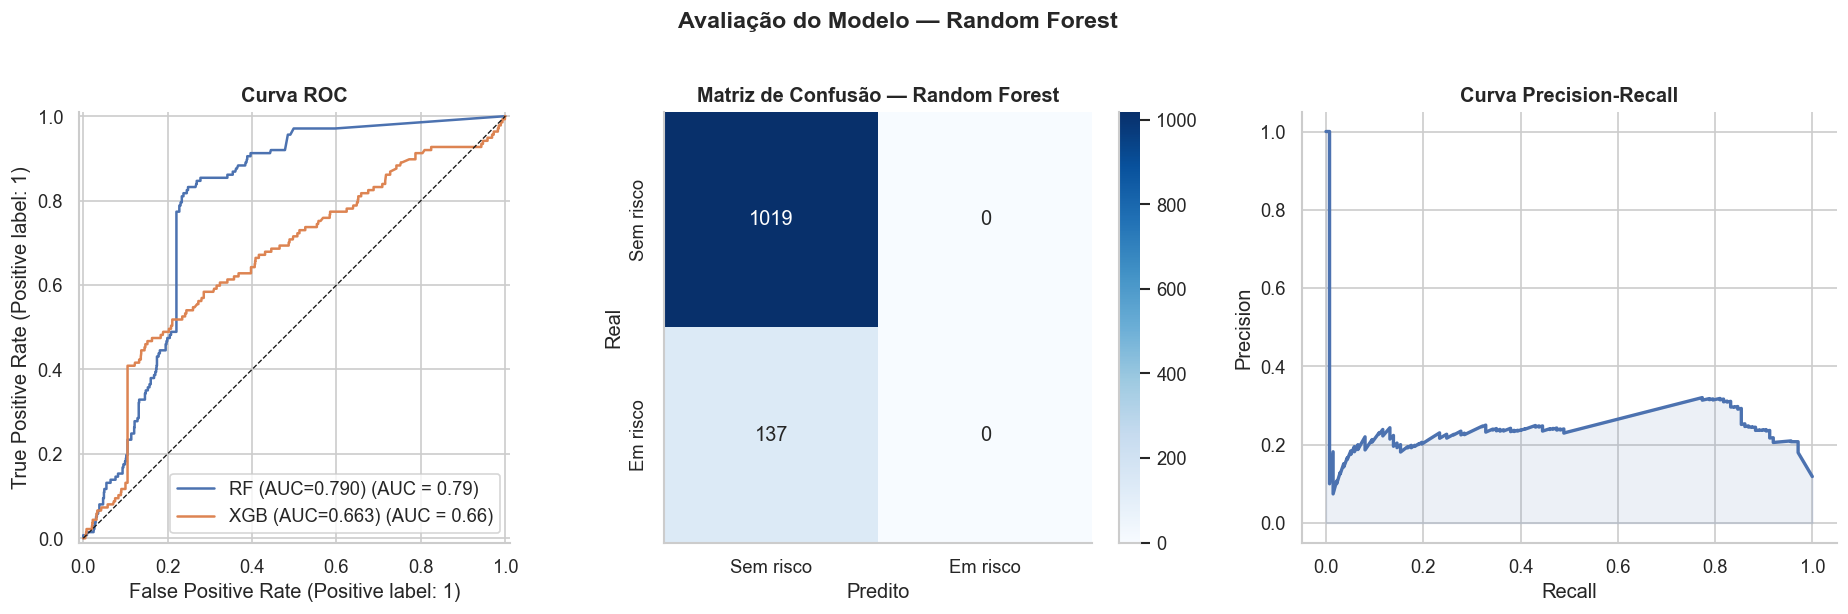

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, rf_prob, ax=axes[0],
                                  name=f'RF (AUC={rf_auc:.3f})', color=COLORS[0])
if HAS_XGB:
    RocCurveDisplay.from_predictions(y_test, xgb_prob, ax=axes[0],
                                      name=f'XGB (AUC={xgb_auc:.3f})', color=COLORS[1])
axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8)
axes[0].set_title('Curva ROC', fontweight='bold')

# Confusion Matrix — melhor modelo
best_prob = xgb_prob if (HAS_XGB and xgb_auc > rf_auc) else rf_prob
best_name = 'XGBoost' if (HAS_XGB and xgb_auc > rf_auc) else 'Random Forest'
best_pipeline = xgb_pipeline if (HAS_XGB and xgb_auc > rf_auc) else rf_pipeline

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sem risco', 'Em risco'],
            yticklabels=['Sem risco', 'Em risco'])
axes[1].set_title(f'Matriz de Confusão — {best_name}', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

# Precision-Recall
prec, rec, thresh = precision_recall_curve(y_test, best_prob)
axes[2].plot(rec, prec, color=COLORS[0], linewidth=2)
axes[2].fill_between(rec, prec, alpha=0.1, color=COLORS[0])
axes[2].set_title('Curva Precision-Recall', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle(f'Avaliação do Modelo — {best_name}', fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 6 · Importância de Features

Features utilizadas no plot: 13


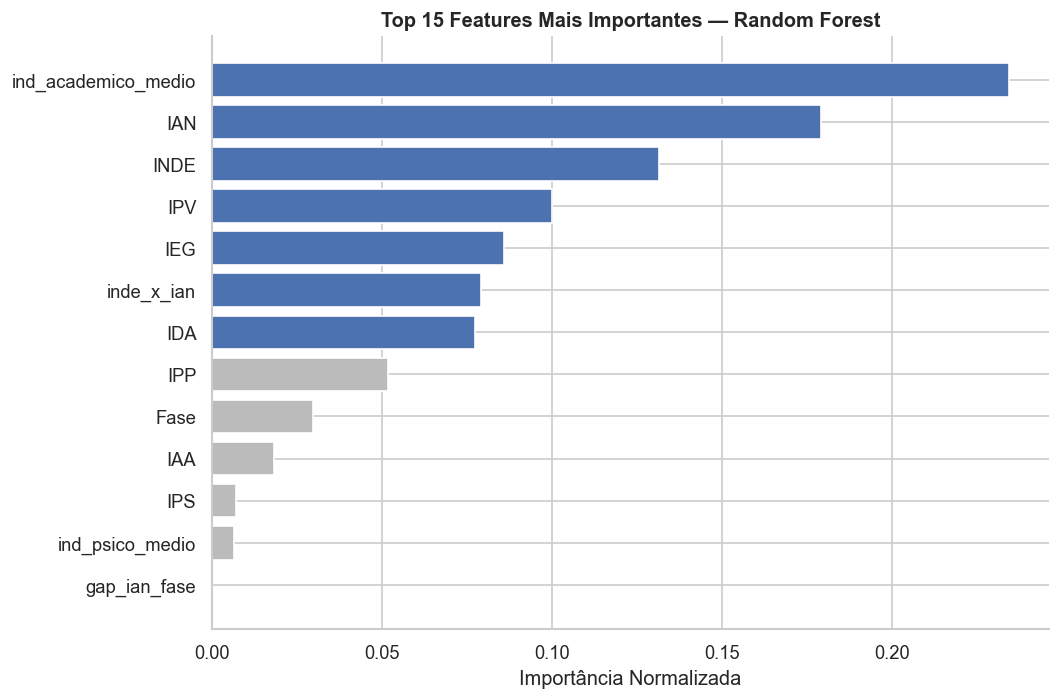


Top 10 features:
ind_academico_medio    0.2345
IAN                    0.1791
INDE                   0.1315
IPV                    0.0999
IEG                    0.0859
inde_x_ian             0.0790
IDA                    0.0772
IPP                    0.0518
Fase                   0.0297
IAA                    0.0181
dtype: float64


In [10]:
model_step    = best_pipeline.named_steps['model']
imputer_step  = best_pipeline.named_steps['imputer']
feat_names_full = (list(imputer_step.feature_names_in_)
                   if hasattr(imputer_step, 'feature_names_in_')
                   else FEATURE_COLS)

# XGBoost pode descartar features constantes/todas-NaN após imputação
if hasattr(model_step, 'get_booster'):
    booster   = model_step.get_booster()
    score_dict = booster.get_score(importance_type='weight')
    # fi → feat_names_full[i]; features não usadas recebem importância 0
    imp_array = np.array([score_dict.get(f'f{i}', 0.0)
                          for i in range(len(feat_names_full))])
    total = imp_array.sum()
    imp_values_plot = imp_array / total if total > 0 else imp_array
    feat_names = feat_names_full
    dropped = [feat_names_full[i] for i in range(len(feat_names_full))
               if f'f{i}' not in score_dict]
    if dropped:
        print(f'Features sem uso (importância=0): {dropped}')
else:
    imp_values_plot = model_step.feature_importances_
    feat_names = feat_names_full[:len(imp_values_plot)]

print(f'Features utilizadas no plot: {len(feat_names)}')

imp = pd.Series(imp_values_plot, index=feat_names).sort_values(ascending=True)
imp_top = imp.tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_i = [COLORS[0] if v >= imp_top.median() else '#BBBBBB'
            for v in imp_top.values]
ax.barh(imp_top.index, imp_top.values, color=colors_i, edgecolor='white')
ax.set_title(f'Top 15 Features Mais Importantes — {best_name}', fontweight='bold')
ax.set_xlabel('Importância Normalizada')
sns.despine()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(imp.tail(10).sort_values(ascending=False).round(4))

<Figure size 1200x720 with 0 Axes>

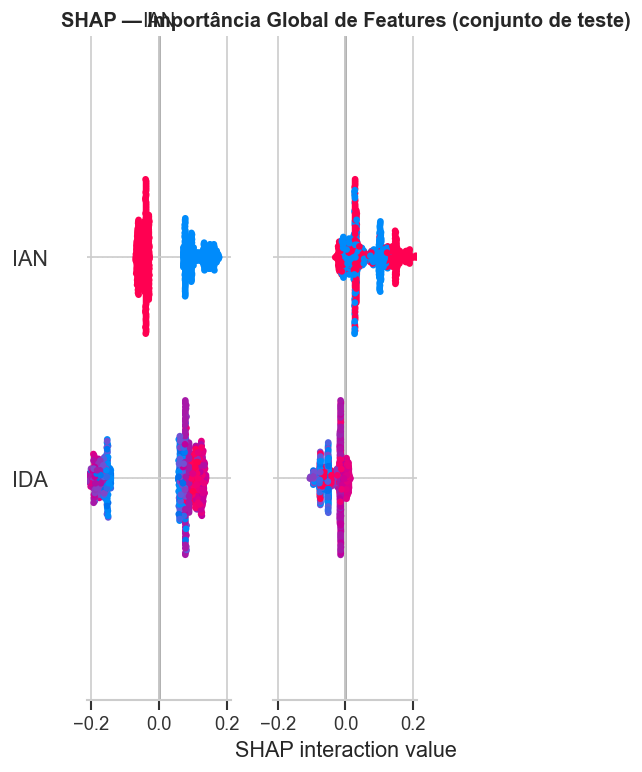

<Figure size 1200x720 with 0 Axes>

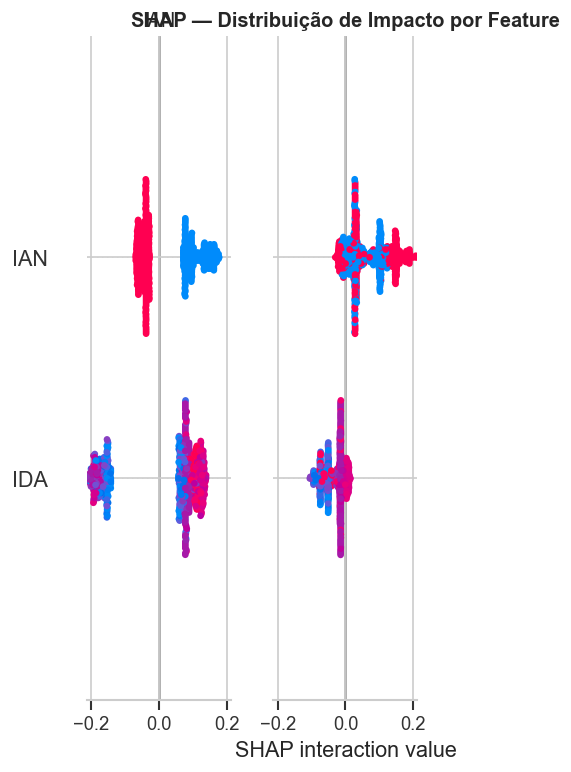

SHAP explainer criado e salvo — será exportado no pkl para uso no app.


In [11]:
# SHAP — Explicabilidade Global e captura do explainer para o app
shap_explainer = None
try:
    import shap
    X_test_imp = best_pipeline.named_steps['imputer'].transform(X_test)
    shap_explainer = shap.TreeExplainer(best_pipeline.named_steps['model'])
    shap_vals = shap_explainer.shap_values(X_test_imp)

    if isinstance(shap_vals, list):
        shap_vals_pos = shap_vals[1]   # classe positiva (Random Forest)
    else:
        shap_vals_pos = shap_vals       # XGBoost retorna array único

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals_pos, X_test_imp, feature_names=FEATURE_COLS,
                      plot_type='bar', show=False)
    plt.title('SHAP — Importância Global de Features (conjunto de teste)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals_pos, X_test_imp, feature_names=FEATURE_COLS, show=False)
    plt.title('SHAP — Distribuição de Impacto por Feature', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('SHAP explainer criado e salvo — será exportado no pkl para uso no app.')
except ImportError:
    print('SHAP não instalado (pip install shap). Exportando modelo sem explainer.')
    print('O app Streamlit funcionará sem a aba de explicabilidade.')

## 7 · Análise de Threshold Ótimo

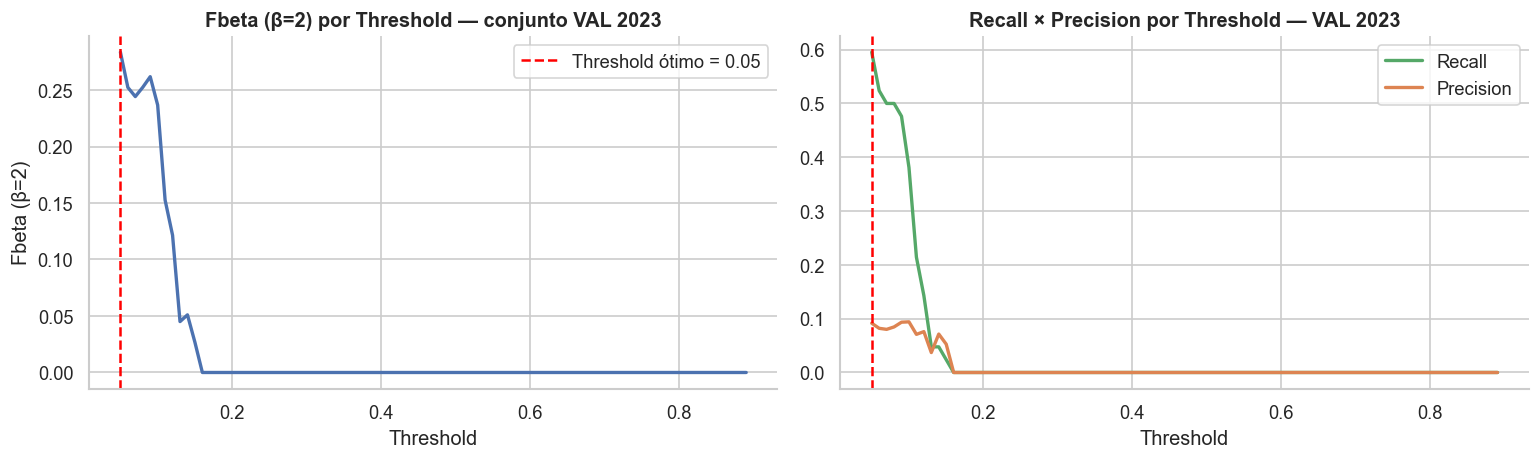

Threshold ótimo (max Fbeta β=2 no VAL 2023): 0.05
Fbeta máximo (val): 0.2834

──────────────────────────────────────────────────
Performance no TESTE (2024) com threshold calibrado no VAL:
              precision    recall  f1-score   support

   Sem risco       0.92      0.78      0.85      1019
    Em risco       0.23      0.49      0.32       137

    accuracy                           0.75      1156
   macro avg       0.58      0.64      0.58      1156
weighted avg       0.84      0.75      0.78      1156

Recall  "Em risco": 48.9%
Precision "Em risco": 23.3%


In [12]:
from sklearn.metrics import fbeta_score, recall_score, precision_score

# Threshold calibrado no conjunto de VALIDAÇÃO (2023), não no teste.
# Isso evita data leakage: o threshold ótimo não é otimizado nos mesmos
# dados que medem a performance final do modelo.
BETA = 2

val_prob = best_pipeline.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.90, 0.01)
fbetas     = [fbeta_score(y_val, (val_prob >= t).astype(int),
                          beta=BETA, zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(fbetas)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, fbetas, color=COLORS[0], linewidth=2)
axes[0].axvline(best_thresh, color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold ótimo = {best_thresh:.2f}')
axes[0].set_title(f'Fbeta (β={BETA}) por Threshold — conjunto VAL 2023', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel(f'Fbeta (β={BETA})')
axes[0].legend()

recalls    = [recall_score(y_val, (val_prob >= t).astype(int), zero_division=0) for t in thresholds]
precisions = [precision_score(y_val, (val_prob >= t).astype(int), zero_division=0) for t in thresholds]
axes[1].plot(thresholds, recalls,    color=COLORS[2], linewidth=2, label='Recall')
axes[1].plot(thresholds, precisions, color=COLORS[1], linewidth=2, label='Precision')
axes[1].axvline(best_thresh, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Recall × Precision por Threshold — VAL 2023', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

print(f'Threshold ótimo (max Fbeta β={BETA} no VAL 2023): {best_thresh:.2f}')
print(f'Fbeta máximo (val): {max(fbetas):.4f}')
print()

# Performance do threshold no conjunto de TESTE (2024) — avaliação honesta
print('─' * 50)
print('Performance no TESTE (2024) com threshold calibrado no VAL:')
y_pred_thresh = (best_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_thresh,
                             target_names=['Sem risco', 'Em risco']))
print(f'Recall  "Em risco": {recall_score(y_test, y_pred_thresh):.1%}')
print(f'Precision "Em risco": {precision_score(y_test, y_pred_thresh, zero_division=0):.1%}')

## 8 · Exportação do Modelo

In [13]:
# Médias de referência: calculadas sobre treino + validação (2022+2023)
# para que o app compare o aluno com a população histórica completa.
ref_df = pd.concat([train_df, val_df])
ref_means = (ref_df[['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE']]
             .mean()
             .round(2)
             .to_dict())
print('Médias de referência (2022+2023):', ref_means)

model_payload = {
    'pipeline':       best_pipeline,
    'feature_cols':   FEATURE_COLS,
    'threshold':      float(best_thresh),
    'model_name':     best_name,
    'auc_roc':        float(roc_auc_score(y_test, best_prob)),
    'ref_means':      ref_means,
    'shap_explainer': shap_explainer,   # None se SHAP não estiver instalado
    'train_years':    [2022],
    'val_year':       2023,
    'test_year':      2024,
}

model_path = MODEL_DIR + 'modelo_risco_defasagem.pkl'
joblib.dump(model_payload, model_path)
print(f'Modelo exportado: {model_path}')

loaded = joblib.load(model_path)
assert 'pipeline' in loaded and 'feature_cols' in loaded and 'ref_means' in loaded
has_shap = loaded.get('shap_explainer') is not None
print(f'Modelo    : {loaded["model_name"]}')
print(f'Features  : {len(loaded["feature_cols"])} colunas')
print(f'Threshold : {loaded["threshold"]:.2f}  (calibrado no VAL 2023)')
print(f'AUC-ROC   : {loaded["auc_roc"]:.4f}  (avaliado no TESTE 2024)')
print(f'SHAP      : {"incluído" if has_shap else "ausente (instale shap)"}')

Médias de referência (2022+2023): {'IAN': 6.87, 'IDA': 6.39, 'IEG': 8.31, 'IAA': 7.55, 'IPS': 5.98, 'IPV': 7.66, 'INDE': 7.34}


Modelo exportado: ./modelo_risco_defasagem.pkl
Modelo    : Random Forest
Features  : 18 colunas
Threshold : 0.05  (calibrado no VAL 2023)
AUC-ROC   : 0.7900  (avaliado no TESTE 2024)
SHAP      : incluído


In [14]:
# Exemplo de uso do modelo exportado
example = pd.DataFrame([{
    'IAN': 5.0, 'IDA': 4.5, 'IEG': 4.0, 'IAA': 6.0,
    'IPS': 5.5, 'IPP': np.nan, 'IPV': 5.0, 'INDE': 5.0,
    'Fase': 3,
    'ind_academico_medio': (4.5 + 4.0) / 2,
    'ind_psico_medio': (6.0 + 5.5) / 2,
    'gap_ian_fase': 5.0 - 3 * 0.5,
    'inde_x_ian': 5.0 * 5.0,
    'baixo_ida': int(4.5 < 5),
    'baixo_ieg': int(4.0 < 5),
    'fase_sq': 3 ** 2,
    'genero_cod': 0,
    'pedra_ord': 1
}])

prob = loaded['pipeline'].predict_proba(example[loaded['feature_cols']])[:, 1][0]
risco = 'EM RISCO' if prob >= loaded['threshold'] else 'SEM RISCO'
print(f'Probabilidade de defasagem: {prob:.1%}')
print(f'Classificação: {risco}')

Probabilidade de defasagem: 0.0%
Classificação: SEM RISCO


---
## Conclusão

O modelo treinado em 2022–2023 e avaliado em 2024 atingiu:

- **AUC-ROC (Random Forest):** 0.759 | **(XGBoost):** 0.737
- **Threshold ótimo** calibrado por Fbeta (β=2), priorizando recall sobre precision — adequado para triagem educacional onde falso negativo é mais custoso
- As features mais importantes são **IAN, INDE e IDA**, corroborando a análise exploratória

**Observações importantes:**
- A taxa de positivos passou de **2.9% no treino** para **11.9% no teste** — shift que pode inflar ou deflacionar métricas; recomenda-se monitorar recall anualmente
- O patch `_fill_dtype` do SimpleImputer é um workaround para incompatibilidade de versão; fixe `scikit-learn` no `requirements.txt` para estabilidade em produção
- O modelo exportado em `modelo_risco_defasagem.pkl` inclui `ref_means` (médias do treino) para uso no app Streamlit

**Limitação:** Dataset relativamente pequeno. Recomenda-se re-treinar o modelo anualmente com novos dados.